In [85]:
import torch
import numpy as np
import random

def set_seed(seed=42):
    """Set the seed for all random generators (for reproducibility)"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # for multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Call the function
set_seed(5)

# Loading Dataset

In [86]:
import pandas as pd
import numpy as np

# Load the dataset from csv
full_dataset = pd.read_csv("dataset.csv")

# Drop missing values
full_dataset = full_dataset.dropna()

print(full_dataset.head())



   id  Gender   Age           City Profession  Academic Pressure  \
0   2    Male  33.0  Visakhapatnam    Student                5.0   
1   8  Female  24.0      Bangalore    Student                2.0   
2  26    Male  31.0       Srinagar    Student                3.0   
3  30  Female  28.0       Varanasi    Student                3.0   
4  32  Female  25.0         Jaipur    Student                4.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  8.97                 2.0               0.0   
1            0.0  5.90                 5.0               0.0   
2            0.0  7.03                 5.0               0.0   
3            0.0  5.59                 2.0               0.0   
4            0.0  8.13                 3.0               0.0   

      Sleep Duration Dietary Habits   Degree  \
0          5-6 hours        Healthy  B.Pharm   
1          5-6 hours       Moderate      BSc   
2  Less than 5 hours        Healthy       BA   
3          7-8

In [87]:
# Display details for each column
for col, dtype in zip(full_dataset.columns, full_dataset.dtypes):
    print(f"{col} ({str(dtype)}): {full_dataset[col].nunique()} unique values")


id (int64): 27898 unique values
Gender (object): 2 unique values
Age (float64): 34 unique values
City (object): 52 unique values
Profession (object): 14 unique values
Academic Pressure (float64): 6 unique values
Work Pressure (float64): 3 unique values
CGPA (float64): 332 unique values
Study Satisfaction (float64): 6 unique values
Job Satisfaction (float64): 5 unique values
Sleep Duration (object): 5 unique values
Dietary Habits (object): 4 unique values
Degree (object): 28 unique values
Have you ever had suicidal thoughts ? (object): 2 unique values
Work/Study Hours (float64): 13 unique values
Financial Stress (float64): 5 unique values
Family History of Mental Illness (object): 2 unique values
Depression (int64): 2 unique values


In [88]:
# Statistical data for each column
print(full_dataset.describe())


                  id           Age  Academic Pressure  Work Pressure  \
count   27898.000000  27898.000000       27898.000000   27898.000000   
mean    70442.953402     25.822174           3.141336       0.000430   
std     40642.015063      4.905651           1.381462       0.043994   
min         2.000000     18.000000           0.000000       0.000000   
25%     35040.750000     21.000000           2.000000       0.000000   
50%     70689.000000     25.000000           3.000000       0.000000   
75%    105824.750000     30.000000           4.000000       0.000000   
max    140699.000000     59.000000           5.000000       5.000000   

               CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  \
count  27898.000000        27898.000000      27898.000000      27898.000000   
mean       7.656160            2.943974          0.000681          7.156570   
std        1.470708            1.361122          0.044397          3.707598   
min        0.000000            0.00

# Data Pre-Processing

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


# Filter to only students (for consistency)
dataset = full_dataset[full_dataset["Profession"] == "Student"].reset_index(drop=True)

# NOTE: Drop unnecessary variables (This is up for debate!)
# Here's my general reasoning:
# - id: Just a counter, not a relevant value
# - City: This didn't really have any strong effect in testing, and if we want a general model, it doesn't really make sense to include
# - Profession, Work Pressure, Job Satisfaction: Since we're working with students only, there were only like three data points for these values,
#     so I just sorted to only include students, and dropped the profession-based variables
dataset = dataset.drop(columns=["id", "City", "Profession", "Work Pressure", "Job Satisfaction"])

# Remove "Others" responses from Sleep Duration (for clean ordinal value)
dataset = dataset[dataset["Sleep Duration"] != "Others"].copy()
sleep_mapping = {
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    '7-8 hours': 3,
    'More than 8 hours': 4
}

# Add interaction terms
dataset["Pressure_x_Sleep"] = dataset["Academic Pressure"] * dataset["Sleep Duration"].map(sleep_mapping)
dataset["Pressure_x_Stress"] = dataset["Academic Pressure"] * dataset["Financial Stress"]
dataset["Stress_x_Sleep"] = dataset["Financial Stress"] * dataset["Sleep Duration"].map(sleep_mapping)
dataset["Pressure_x_Satisfaction"] = dataset["Academic Pressure"] * dataset["Study Satisfaction"]

interaction_terms = ["Pressure_x_Sleep", "Pressure_x_Stress", "Stress_x_Sleep", "Pressure_x_Satisfaction"]

# Separate the target variable (y)
X = dataset.drop('Depression', axis=1)
y = dataset['Depression']

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Group columns by data type
numeric_features = [
    'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress'
] + interaction_terms
categorical_features = [
    'Gender', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 
    'Family History of Mental Illness'
]

# Column transformer will convert data into usable numeric values for models to use
preprocessor = ColumnTransformer(
    transformers=[
        # Numerical values are already the correct type, so just scale to unit variance
        ('num', StandardScaler(), numeric_features),
        # Categorical variables are one-hot encoded, and then drop the first of each category (so we don't have two variables each for True/False values)
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features.copy())
    ]
)

# Apply the preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original X_train shape: {X_train.shape}")
print(f"Processed X_train shape: {X_train_processed.shape}")

Original X_train shape: (22279, 16)
Processed X_train shape: (22279, 46)


# Functions/Tools

## Model Evaluation Tools

In [90]:
from sklearn.metrics import accuracy_score, average_precision_score, brier_score_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, matthews_corrcoef, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
import torch
import torch.nn as nn

def evaluate_model(model, X_test, y_test, name="Model", show_plots=True, threshold=0.5):
    """Evaluate the provided model. Calculates a variety of metrics and (optionally) displays results"""
    metrics = {"Model": name}
    y_proba = None
    y_score = None

    # Handle PyTorch models
    if isinstance(model, nn.Module):
        model.eval()
        # Convert to tensor
        if not torch.is_tensor(X_test):
            if hasattr(X_test, "toarray"):
                X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32)
            else:
                X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        else:
            X_test_tensor = X_test

        with torch.no_grad():
            outputs = model(X_test_tensor)
            if outputs.shape[1] == 1:
                y_proba = outputs.squeeze().cpu().numpy()
            else:
                y_proba = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        
        y_score = y_proba
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_proba)
        metrics["Brier_Score"] = brier_score_loss(y_test, y_proba)
        y_pred = (y_proba >= threshold).astype(int)

    elif hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        y_score = y_proba
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_proba)
        metrics["Brier_Score"] = brier_score_loss(y_test, y_proba)
        
        # Apply the threshold
        y_pred = (y_proba >= threshold).astype(int)
    
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_score)
        metrics["Brier_Score"] = None
        
        # Fallback to standard prediction if no probabilities
        y_pred = model.predict(X_test)

    else:
        y_pred = model.predict(X_test)
        metrics["ROC-AUC"] = None
        metrics["Brier_Score"] = None

    # Calculate other prediction metrics
    metrics["Accuracy"] = accuracy_score(y_test, y_pred)
    metrics["Precision"] = precision_score(y_test, y_pred, zero_division=0)
    metrics["Recall"] = recall_score(y_test, y_pred, zero_division=0)
    metrics["F1_Score"] = f1_score(y_test, y_pred, zero_division=0)
    metrics["MCC"] = matthews_corrcoef(y_test, y_pred)
    metrics["AP"] = average_precision_score(y_test, y_score) if y_score is not None else None

    # Display the results
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))
    if metrics["ROC-AUC"] is not None:
        print(f"ROC-AUC: {metrics['ROC-AUC']:.4f}")
    if metrics["Brier_Score"] is not None:
        print(f"Brier Score: {metrics['Brier_Score']:.4f}")
    print(f"MCC: {metrics['MCC']:.4f}")

    if show_plots:
        # Display the confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Not Depressed", "Depressed"]
        )
        disp.plot(cmap="Blues")
        plt.title(f"{name} Confusion Matrix")
        
        if y_proba is not None:
            # Display the ROC curve
            fpr, tpr, _ = roc_curve(y_test, y_proba)

            # Compute Precision-Recall
            precision, recall, _ = precision_recall_curve(y_test, y_proba)
            ap = average_precision_score(y_test, y_proba)

            fig, axes = plt.subplots(1, 2, figsize=(12, 5))

            # ROC Curve
            axes[0].plot(fpr, tpr, label=f"AUC = {metrics["ROC-AUC"]:.3f}")
            axes[0].plot([0, 1], [0, 1], linestyle="--")
            axes[0].set_xlabel("False Positive Rate")
            axes[0].set_ylabel("True Positive Rate")
            axes[0].set_title(f"{name} ROC Curve")
            axes[0].legend()
        
            # Precision-Recall Curve
            baseline = sum(y_test) / len(y_test)
            axes[1].plot(recall, precision, label=f"AP = {ap:.3f}")
            axes[1].hlines(baseline, 0, 1, linestyles="--", label="Baseline")
            axes[1].set_xlabel("Recall")
            axes[1].set_ylabel("Precision")
            axes[1].set_title(f"{name} Precision-Recall Curve")
            axes[1].legend()

            plt.tight_layout()

        plt.show()

    return metrics

def show_feature_importance(model, preprocessor, top_n=10):
    feature_names = preprocessor.get_feature_names_out()
    coefficients = model.coef_[0]

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    feature_importance = feature_importance.sort_values(
        by="Coefficient",
        ascending=False
    )

    print(f"\n--- Top {top_n} Features Increasing Risk ---")
    print(feature_importance.head(top_n).to_string(index=False))

    print(f"\n--- Top {top_n} Features Decreasing Risk ---")
    print(feature_importance.tail(top_n).to_string(index=False))

def cross_validate_model(model, X, y, cv=5, scoring="roc_auc", name="Model"):
    """Perform K-fold cross validation, returning the list of scores"""
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    print(f"\n--- {name} {cv}-Fold Cross-Validation ({scoring}) ---")
    print(f"Individual Fold Scores: {['{:.4f}'.format(s) for s in scores]}")
    print(f"Mean Score: {scores.mean():.4f}")
    print(f"Standard Deviation: +/- {scores.std():.4f}")
    
    return scores

def evaluate_sparsity(model) -> int:
    coef = model.coef_[0]
    non_zero = np.sum(coef != 0)
    total = len(coef)
    print(f"Non-zero features: {non_zero}")
    print(f"Total features: {total}")
    print(f"Sparsity: {100 * (1 - non_zero/total):.2f}% features removed")
    return non_zero


import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_gridsearch_param(
    grid_search,
    param_name: str,
    use_log_scale: bool = True,
    selected_value: float = None
):
    """Plot score vs. a hyperparameter (to select best value for a minimal model)"""
    results = pd.DataFrame(grid_search.cv_results_)

    param_col = f"param_{param_name}"
    if param_col not in results:
        raise ValueError(f"Parameter '{param_name}' not found.")

    x = results[param_col].astype(float)
    y = results["mean_test_score"]
    std = results["std_test_score"]

    # Sort for clean plotting
    order = np.argsort(x)
    x, y, std = x.iloc[order], y.iloc[order], std.iloc[order]

    # Best point
    best_idx = y.idxmax()
    best_x = results.loc[best_idx, param_col]
    best_y = results.loc[best_idx, "mean_test_score"]
    best_std = results.loc[best_idx, "std_test_score"]

    upper = best_y + best_std
    lower = best_y - best_std

    plt.figure()

    # Main curve
    plt.plot(x, y, marker="o", label="Mean CV Score")

    # Highlight best point
    plt.scatter(best_x, best_y, color="red", zorder=3, label="Best")

    # Horizontal std band
    plt.axhspan(lower, upper, alpha=0.15, label="±1 std (best)")

    if selected_value is not None:
        selected_value = float(selected_value)
        selected_y = np.interp(selected_value, x, y)  # approximate y-position

        plt.scatter(
            selected_value,
            selected_y,
            color="green",
            s=100,
            zorder=4,
            label=f"Selected {param_name} = {selected_value:.4f}"
        )
        plt.axvline(selected_value, color="red", linestyle="--", alpha=0.5)

    plt.xlabel(param_name)
    plt.ylabel("Mean Test Score")
    plt.title(f"{param_name} vs Cross-Validated Score")
    plt.grid(True)

    if use_log_scale:
        plt.xscale("log")

    plt.legend()
    plt.tight_layout()
    plt.show()


In [91]:
def find_best_threshold(y_true, y_proba, target_recall=None, target_precision=None):
    """Find threshold based on target recall or precision"""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    thresholds = np.append(thresholds, 1.0)  # Fix array size difference

    # Target recall
    if target_recall is not None:
        valid_idx = np.where(recall >= target_recall)[0]
        if len(valid_idx) == 0:
            return None
        
        best_idx = valid_idx[np.argmax(precision[valid_idx])]

    # Target precision
    elif target_precision is not None:
        valid_idx = np.where(precision >= target_precision)[0]
        if len(valid_idx) == 0:
            return None
        
        best_idx = valid_idx[np.argmax(recall[valid_idx])]

    else:
        raise ValueError("Provide either target_recall or target_precision")

    return {
        "threshold": thresholds[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx]
    }

# Logistic Regression

## Standard (All predictors)


--- Standard LR 5-Fold Cross-Validation (roc_auc) ---
Individual Fold Scores: ['0.9247', '0.9142', '0.9231', '0.9275', '0.9160']
Mean Score: 0.9211
Standard Deviation: +/- 0.0051

--- Full (46 features) Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.84      0.82      2310
           1       0.88      0.85      0.87      3260

    accuracy                           0.85      5570
   macro avg       0.84      0.85      0.84      5570
weighted avg       0.85      0.85      0.85      5570

ROC-AUC: 0.9209
Brier Score: 0.1112
MCC: 0.6901


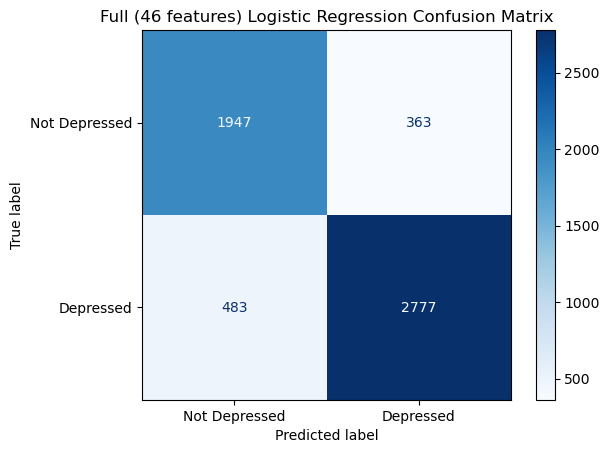

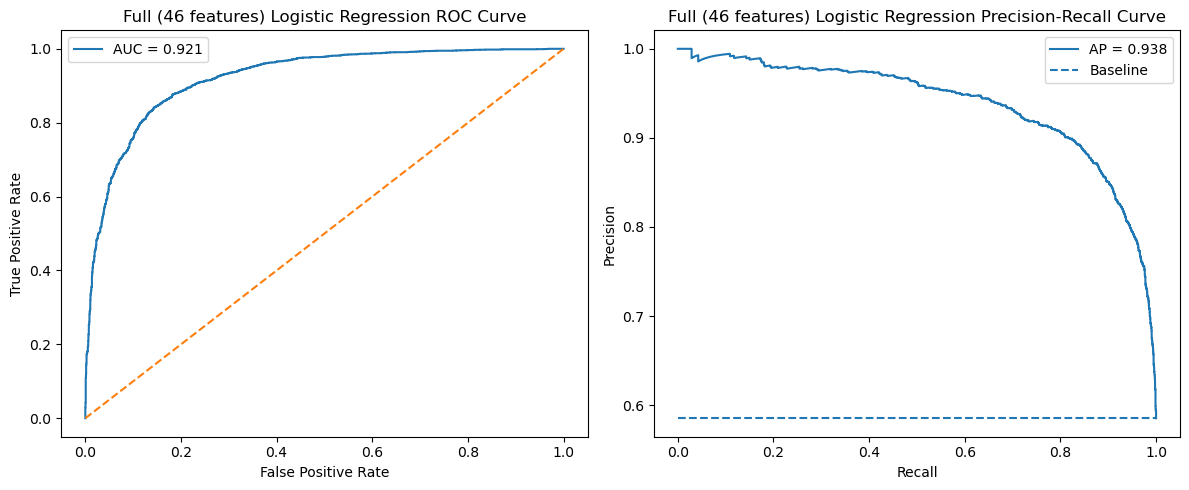


--- Top 10 Features Increasing Risk ---
                                       Feature  Coefficient
cat__Have you ever had suicidal thoughts ?_Yes     2.506180
                        num__Academic Pressure     1.288971
                 cat__Dietary Habits_Unhealthy     1.076514
                         num__Financial Stress     0.764731
                  cat__Dietary Habits_Moderate     0.466542
                         num__Work/Study Hours     0.437301
         cat__Sleep Duration_Less than 5 hours     0.390172
     cat__Family History of Mental Illness_Yes     0.267562
                    cat__Dietary Habits_Others     0.112688
                               cat__Degree_LLM     0.102870

--- Top 10 Features Decreasing Risk ---
                              Feature  Coefficient
         num__Pressure_x_Satisfaction    -0.195560
              num__Study Satisfaction    -0.199710
                    cat__Degree_B.Com    -0.229124
                       cat__Degree_MA    -0.231638
   

In [92]:
from sklearn.linear_model import LogisticRegression

# Build the logistic regression model ("balanced" means classes are given equal weight)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train the model
log_reg.fit(X_train_processed, y_train)

# Do cross-validation to check consistency
cv_scores = cross_validate_model(log_reg, X_train_processed, y_train, cv=5, name="Standard LR")

# Evaluate the model
evaluate_model(log_reg, X_test_processed, y_test, f"Full ({len(log_reg.coef_[0])} features) Logistic Regression")

# Rank features by importance
show_feature_importance(log_reg, preprocessor)


## Sparse (Using Lasso Regression)

Running Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Optimal 'C' within margin: 0.0112


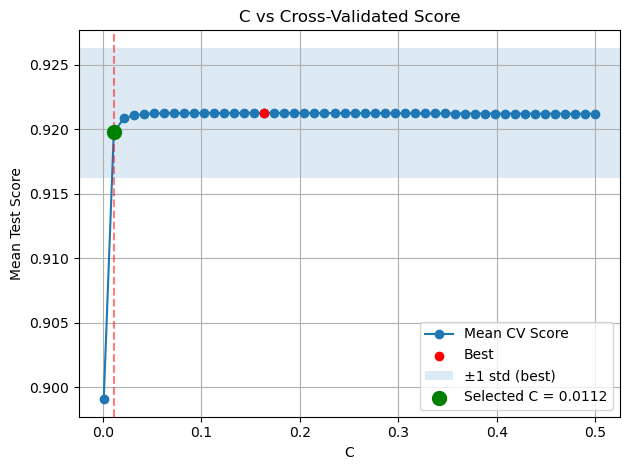

Non-zero features: 14
Total features: 46
Sparsity: 69.57% features removed

--- Sparse (14 features) LR 5-Fold Cross-Validation (roc_auc) ---
Individual Fold Scores: ['0.9242', '0.9130', '0.9213', '0.9256', '0.9146']
Mean Score: 0.9197
Standard Deviation: +/- 0.0051
Threshold Details: (Threshold = 0.3932 | Precision = 0.8500 | Recall = 0.9006

--- Sparse (14 features) Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.78      0.81      2310
           1       0.85      0.90      0.87      3260

    accuracy                           0.85      5570
   macro avg       0.85      0.84      0.84      5570
weighted avg       0.85      0.85      0.85      5570

ROC-AUC: 0.9203
Brier Score: 0.1116
MCC: 0.6866


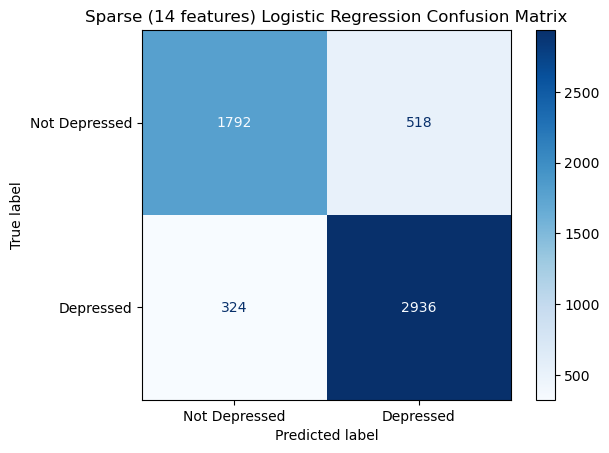

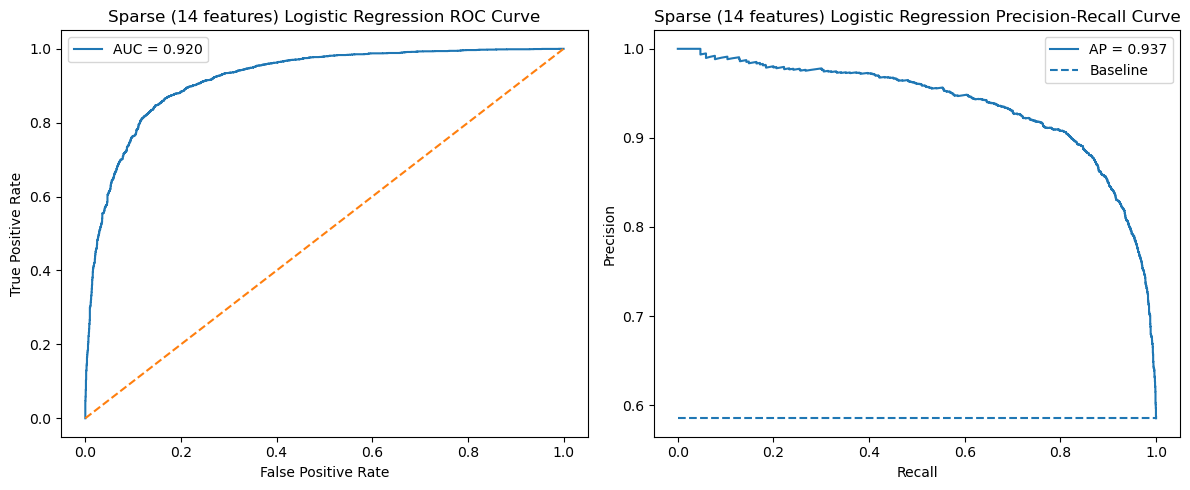


--- Top 10 Features Increasing Risk ---
                                       Feature  Coefficient
cat__Have you ever had suicidal thoughts ?_Yes     2.287036
                        num__Academic Pressure     1.036888
                 cat__Dietary Habits_Unhealthy     0.706668
                         num__Financial Stress     0.680971
                         num__Work/Study Hours     0.385660
         cat__Sleep Duration_Less than 5 hours     0.190622
                  cat__Dietary Habits_Moderate     0.136108
     cat__Family History of Mental Illness_Yes     0.121854
                        num__Pressure_x_Stress     0.096111
                                     num__CGPA     0.054875

--- Top 10 Features Decreasing Risk ---
                              Feature  Coefficient
                     cat__Degree_B.Ed     0.000000
                  cat__Degree_B.Pharm     0.000000
                   cat__Degree_B.Tech     0.000000
                       cat__Degree_BA     0.000000
   

In [108]:
from sklearn.model_selection import GridSearchCV

# Tuning flag - If performance is bad, disable this! (model will use pre-tuned C value from my testing)
TUNE_C = True
DEFAULT_C = 0.02

if TUNE_C:
    # Build the base LR model to evaluate C values
    base_log_reg = LogisticRegression(
        penalty='l1',
        solver="saga",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

    # Test all values of C using 5-fold cross validation (ROC-AUC) to evaluate
    hyper_parameter_grid = {
        'C': np.linspace(0.001, 0.5, 50)
    }
    grid_search = GridSearchCV(
        estimator=base_log_reg,
        param_grid=hyper_parameter_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    print("Running Hyperparameter Tuning...")
    grid_search.fit(X_train_processed, y_train)

    # Keep the best model
    results = pd.DataFrame(grid_search.cv_results_)
    best_index = results['mean_test_score'].idxmax()
    best_score = results.loc[best_index, 'mean_test_score']

    acceptable_threshold = best_score - results['std_test_score']

    # Choose the simplest model within the acceptable threshold
    good_models = results[results["mean_test_score"] >= acceptable_threshold]
    optimal_C = good_models['param_C'].astype(float).min()
    print(f"Optimal 'C' within margin: {optimal_C:.4f}")
    plot_gridsearch_param(grid_search, "C", selected_value=optimal_C, use_log_scale=False)
else:
    # If tuning is disabled, use value from testing
    optimal_C = DEFAULT_C

# Now, train a model with the optimal C
log_reg_sparse = LogisticRegression(
    penalty='l1', 
    solver="saga",
    C=optimal_C,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
log_reg_sparse.fit(X_train_processed, y_train)

# Evaluate sparsity after Lasso
num_features = evaluate_sparsity(log_reg_sparse)

# Do cross-validation to check consistency
cv_scores = cross_validate_model(log_reg_sparse, X_train_processed, y_train, cv=5, name=f"Sparse ({num_features} features) LR")

# Find the best threshold for evaluation (Used to weight TP/FN)
y_proba_test = log_reg_sparse.predict_proba(X_test_processed)[:, 1]
threshold_result = find_best_threshold(y_test, y_proba_test, target_recall=0.90)  # Catch 90% of true positives (avoid false negatives)
print(f"Threshold Details: (Threshold = {threshold_result["threshold"]:.4f} | Precision = {threshold_result["precision"]:.4f} | Recall = {threshold_result["recall"]:.4f}")

# Evaluate the model
evaluate_model(log_reg_sparse, X_test_processed, y_test, f"Sparse ({num_features} features) Logistic Regression", threshold=threshold_result["threshold"])

# Rank features by importance
show_feature_importance(log_reg_sparse, preprocessor)

## Without Suicide Indication (Avoiding leakage)
Because suicide is so closely aligned with depression, including it could be considered data leakage ("Are you suicidal?" is basically the same as "Are you depressed?")

Below is the same logistic regression model trained without the suicide survey point

In [94]:
# Also split a dataset without the suicidal tendency variable (could be leaking?)
categorical_features_no_suicide = categorical_features.copy()
categorical_features_no_suicide.remove('Have you ever had suicidal thoughts ?')

X_train_no_suicide = X_train.drop(columns=["Have you ever had suicidal thoughts ?"])
X_test_no_suicide = X_test.drop(columns=["Have you ever had suicidal thoughts ?"])

preprocessor_no_suicide = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features_no_suicide)
    ]
)

X_train_processed_no_suicide = preprocessor_no_suicide.fit_transform(X_train_no_suicide)
X_test_processed_no_suicide = preprocessor_no_suicide.transform(X_test_no_suicide)

Running Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Optimal 'C' within margin: 0.0112


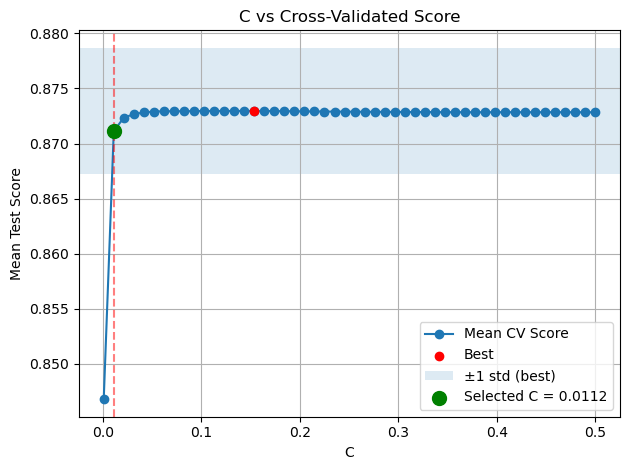

Non-zero features: 12
Total features: 45
Sparsity: 73.33% features removed

--- Sparse (12 features) LR (No Suicide) 5-Fold Cross-Validation (roc_auc) ---
Individual Fold Scores: ['0.8683', '0.8690', '0.8712', '0.8813', '0.8658']
Mean Score: 0.8711
Standard Deviation: +/- 0.0054
Threshold Details: (Threshold = 0.3301 | Precision = 0.7824 | Recall = 0.9000

--- Sparse (12 features) LR (No Suicide) Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.65      0.72      2310
           1       0.78      0.90      0.84      3260

    accuracy                           0.79      5570
   macro avg       0.80      0.77      0.78      5570
weighted avg       0.80      0.79      0.79      5570

ROC-AUC: 0.8686
Brier Score: 0.1474
MCC: 0.5743


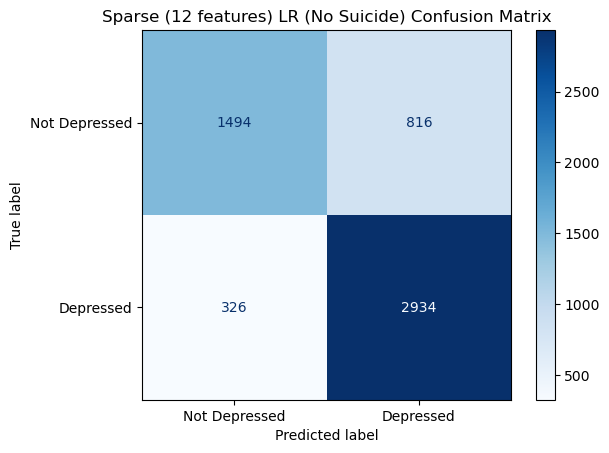

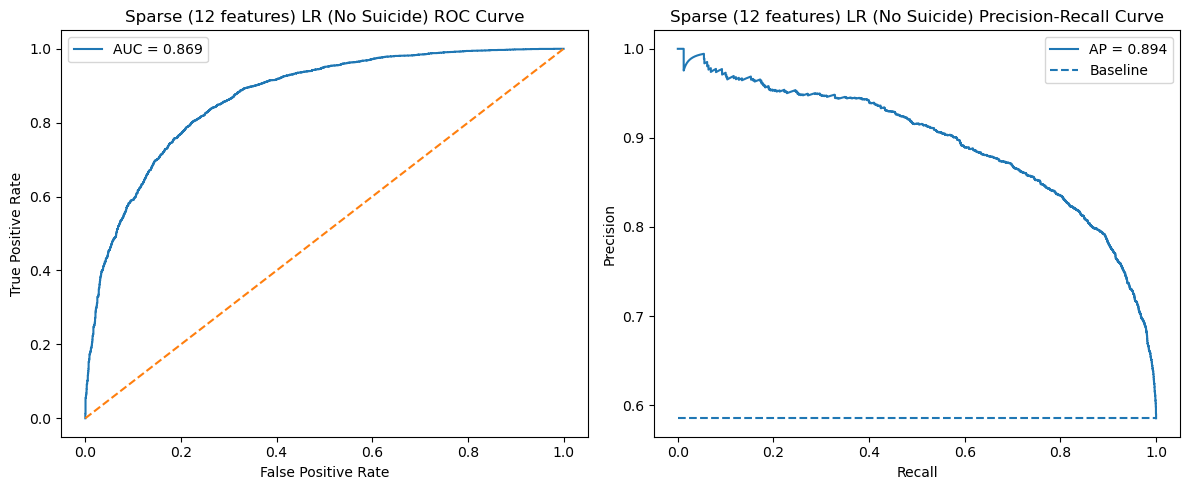


--- Top 10 Features Increasing Risk ---
                                  Feature  Coefficient
                   num__Academic Pressure     1.054393
            cat__Dietary Habits_Unhealthy     0.782737
                    num__Financial Stress     0.726179
                    num__Work/Study Hours     0.407698
             cat__Dietary Habits_Moderate     0.226562
    cat__Sleep Duration_Less than 5 hours     0.222512
cat__Family History of Mental Illness_Yes     0.150775
                   num__Pressure_x_Stress     0.079496
                                num__CGPA     0.055597
                          cat__Degree_LLM     0.000000

--- Top 10 Features Decreasing Risk ---
                              Feature  Coefficient
           cat__Dietary Habits_Others     0.000000
                     cat__Degree_B.Ed     0.000000
                  cat__Degree_B.Pharm     0.000000
                   cat__Degree_B.Tech     0.000000
                       cat__Degree_BA     0.000000
       

In [107]:
TUNE_C = True
DEFAULT_C = 0.02

if TUNE_C:
    # Build the base LR model to evaluate C values
    base_log_reg = LogisticRegression(
        penalty="l1",
        solver="saga",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

    # Test all values of C using 5-fold cross validation (ROC-AUC) to evaluate
    hyper_parameter_grid = {
        'C': np.linspace(0.001, 0.5, 50)
    }
    grid_search = GridSearchCV(
        estimator=base_log_reg,
        param_grid=hyper_parameter_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    print("Running Hyperparameter Tuning...")
    grid_search.fit(X_train_processed_no_suicide, y_train)

    # Keep the best model
    results = pd.DataFrame(grid_search.cv_results_)
    best_index = results['mean_test_score'].idxmax()
    best_score = results.loc[best_index, 'mean_test_score']

    acceptable_threshold = best_score - results['std_test_score']

    # Choose the simplest model within the acceptable threshold
    good_models = results[results["mean_test_score"] >= acceptable_threshold]
    optimal_C = good_models['param_C'].astype(float).min()
    print(f"Optimal 'C' within margin: {optimal_C:.4f}")
    plot_gridsearch_param(grid_search, "C", selected_value=optimal_C, use_log_scale=False)
    
else:
    # If tuning is disabled, use value from testing
    optimal_C = DEFAULT_C

# Now, train a model with the optimal C
log_reg_no_suicide = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=optimal_C,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
log_reg_no_suicide.fit(X_train_processed_no_suicide, y_train)

# Evaluate sparsity after Lasso
num_features = evaluate_sparsity(log_reg_no_suicide)

# Do cross-validation to check consistency
cv_scores = cross_validate_model(log_reg_no_suicide, X_train_processed_no_suicide, y_train, cv=5, name=f"Sparse ({num_features} features) LR (No Suicide)")

# Find the best threshold for evaluation (Used to weight TP/FN)
y_proba_test = log_reg_no_suicide.predict_proba(X_test_processed_no_suicide)[:, 1]
threshold_result = find_best_threshold(y_test, y_proba_test, target_recall=0.90)  # Catch 90% of true positives (avoid false negatives)
print(f"Threshold Details: (Threshold = {threshold_result["threshold"]:.4f} | Precision = {threshold_result["precision"]:.4f} | Recall = {threshold_result["recall"]:.4f}")

# Evaluate the model
evaluate_model(log_reg_no_suicide, X_test_processed_no_suicide, y_test, f"Sparse ({num_features} features) LR (No Suicide)", threshold=threshold_result["threshold"])

# Rank features by importance
show_feature_importance(log_reg_no_suicide, preprocessor_no_suicide)

# Deep Learning

## Tools

In [96]:
import copy

def train_model(model, train_loader, val_loader, optimizer, criterion, lr_scheduler, params):
    """Train the provided model using the provided training and validation data (+params for other variables)"""
    
    best_val_loss = float('inf')
    best_model_wts = None
    patience = params.get("patience", 10)
    counter = 0
    
    for epoch in range(100):
        model.train()
        running_train_loss = 0.0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
        
        avg_train_loss = running_train_loss / len(train_loader)
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_vx, batch_vy in val_loader:
                outputs = model(batch_vx)
                val_loss += criterion(outputs, batch_vy).item()
        
        avg_val_loss = val_loss / len(val_loader)

        lr_scheduler.step(avg_val_loss)
        
        print(f"Epoch [{epoch+1:2d}/100] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # Early Stopping Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"\n--- Early Stopping Triggered! ---")
                print(f"No improvement for {patience} consecutive epochs.")
                break
                
    if best_model_wts:
        model.load_state_dict(best_model_wts)
    
    return model


## Data Pre-Processing

In [97]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import copy

# Create the validation set (split the training set again)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_processed_no_suicide, 
    y_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train
)

def to_tensor(data):
    if hasattr(data, "toarray"): data = data.toarray()
    return torch.tensor(data, dtype=torch.float32)

# Convert to tensors
X_train_t = to_tensor(X_train_final)
y_train_t = torch.tensor(y_train_final.values, dtype=torch.float32).view(-1, 1)
X_val_t = to_tensor(X_val)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# Build data loaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

print(f"Data ready. Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Data ready. Train batches: 279 | Val batches: 70


## Multi-Layer Perceptron

In [98]:
class StudentDepressionMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_rate):
        super(StudentDepressionMLP, self).__init__()
        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

# Build the model, and select an optimizer (for learning rate) and a criterion to check
params = {
    'hidden': [128, 64], 
    'dropout': 0.3, 
    'lr': 0.001, 
    'wd': 1e-5,
    'patience': 10
}
model = StudentDepressionMLP(input_dim=X_train_t.shape[1], hidden_dims=params["hidden"], dropout_rate=params["dropout"])
optimizer = optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["wd"])
criterion = nn.BCELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)


In [99]:
# Train the model (with early stopping)
model = train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, params)

Epoch [ 1/100] | Train Loss: 0.4746 | Val Loss: 0.4368
Epoch [ 2/100] | Train Loss: 0.4461 | Val Loss: 0.4360
Epoch [ 3/100] | Train Loss: 0.4432 | Val Loss: 0.4335
Epoch [ 4/100] | Train Loss: 0.4410 | Val Loss: 0.4367
Epoch [ 5/100] | Train Loss: 0.4405 | Val Loss: 0.4325
Epoch [ 6/100] | Train Loss: 0.4377 | Val Loss: 0.4345
Epoch [ 7/100] | Train Loss: 0.4366 | Val Loss: 0.4353
Epoch [ 8/100] | Train Loss: 0.4355 | Val Loss: 0.4337
Epoch [ 9/100] | Train Loss: 0.4334 | Val Loss: 0.4340
Epoch [10/100] | Train Loss: 0.4305 | Val Loss: 0.4334
Epoch [11/100] | Train Loss: 0.4310 | Val Loss: 0.4343
Epoch [12/100] | Train Loss: 0.4288 | Val Loss: 0.4338
Epoch [13/100] | Train Loss: 0.4279 | Val Loss: 0.4335
Epoch [14/100] | Train Loss: 0.4279 | Val Loss: 0.4340
Epoch [15/100] | Train Loss: 0.4263 | Val Loss: 0.4339

--- Early Stopping Triggered! ---
No improvement for 10 consecutive epochs.



--- Deep Learning MLP Classification Report ---
              precision    recall  f1-score   support

           0       0.77      0.72      0.74      2310
           1       0.81      0.85      0.83      3260

    accuracy                           0.79      5570
   macro avg       0.79      0.78      0.79      5570
weighted avg       0.79      0.79      0.79      5570

ROC-AUC: 0.8699
Brier Score: 0.1427
MCC: 0.5724


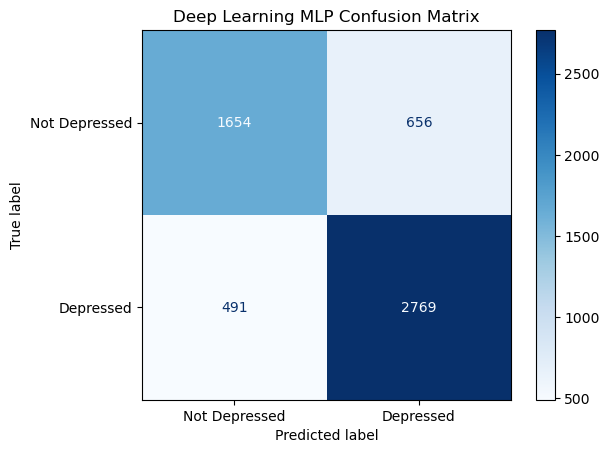

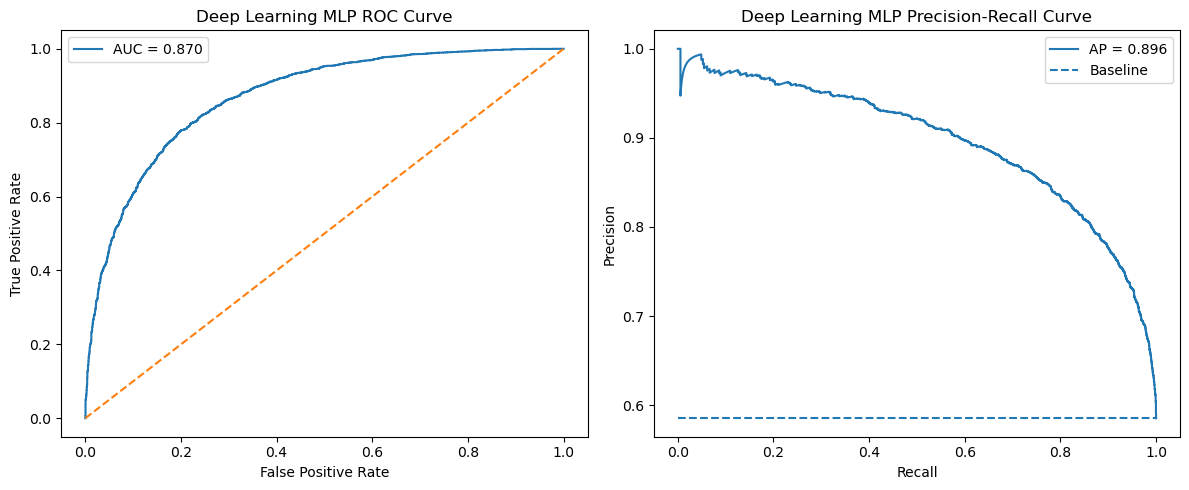

{'Model': 'Deep Learning MLP',
 'ROC-AUC': 0.8698754415318832,
 'Brier_Score': 0.142736137068746,
 'Accuracy': 0.7940754039497308,
 'Precision': 0.8084671532846716,
 'Recall': 0.8493865030674846,
 'F1_Score': 0.8284218399401645,
 'MCC': 0.572439497033338,
 'AP': 0.896126265510442}

In [100]:
evaluate_model(
    model=model, 
    X_test=X_test_processed_no_suicide, 
    y_test=y_test, 
    name="Deep Learning MLP",
    threshold=0.5
)

## K-Nearest Neighbors (KNN)

Starting Grid Search for KNN...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

--- Grid Search Results ---
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 41, 'weights': 'distance'}
Best Cross-Validation AUC: 0.9022
Misclassification Error Rate: 0.1729

--- Optimized KNN Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.73      0.78      2310
           1       0.82      0.89      0.86      3260

    accuracy                           0.83      5570
   macro avg       0.83      0.81      0.82      5570
weighted avg       0.83      0.83      0.83      5570

ROC-AUC: 0.9026
Brier Score: 0.1229
MCC: 0.6410


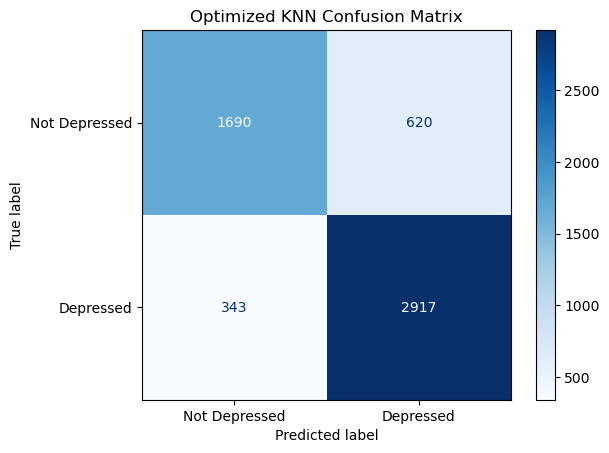

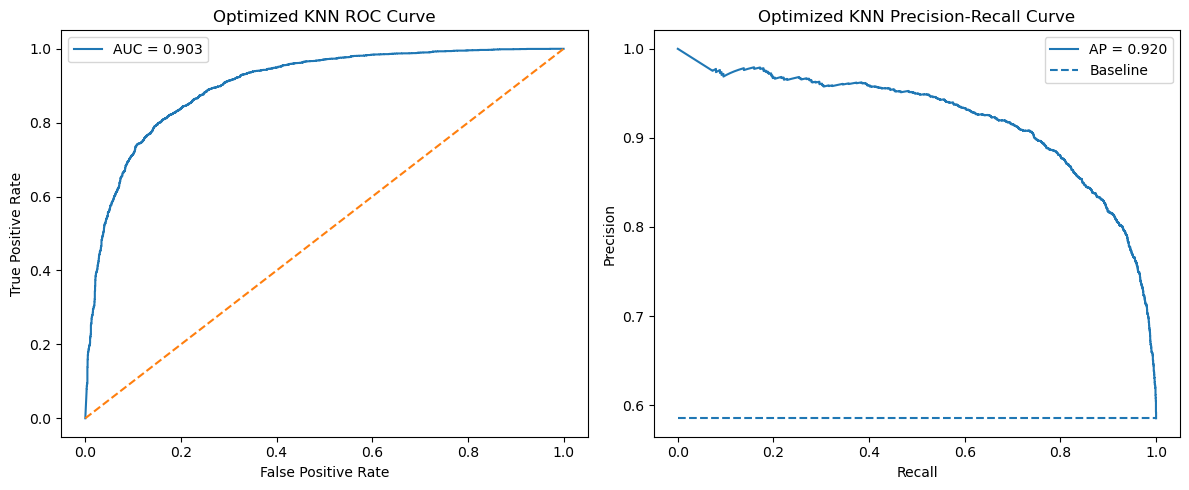

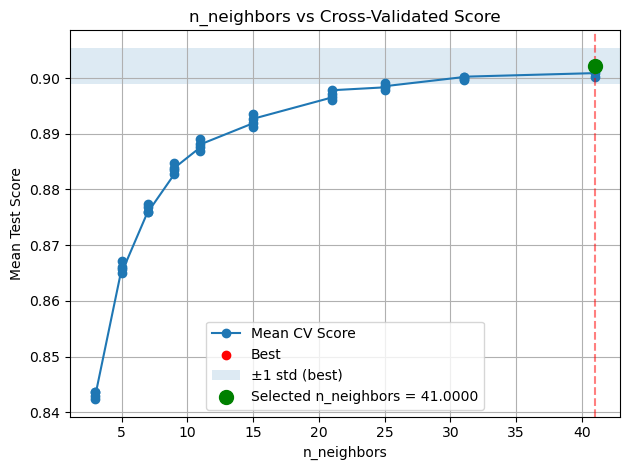

In [101]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

#Initialize the base model
knn = KNeighborsClassifier()

# Define the hyperparameter grid
# We use odd numbers for n_neighbors to prevent tie-breaking issues.
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 25, 31, 41],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Set up GridSearchCV
# We use scoring='roc_auc' because we decided AUC-ROC is our best metric for this medical/imbalanced context
print("Starting Grid Search for KNN...")
grid_search_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='roc_auc',   # Optimizing for Area Under the ROC Curve
    n_jobs=-1,           # Use all available CPU cores to speed up processing
    verbose=1            # Gives a little output so you know it's working
)

# Fit the model on the processed training data
grid_search_knn.fit(X_train_processed, y_train)

# Extract the best model
best_knn = grid_search_knn.best_estimator_

print("\n--- Grid Search Results ---")
print(f"Best Parameters: {grid_search_knn.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search_knn.best_score_:.4f}")

misclassification_rate = 1 - knn_metrics["Accuracy"]
print(f"Misclassification Error Rate: {misclassification_rate:.4f}")

# Evaluate using the custom function
# This will output your classification report, confusion matrix, ROC, and PR curves
knn_metrics = evaluate_model(
    model=best_knn, 
    X_test=X_test_processed, 
    y_test=y_test, 
    name="Optimized KNN", 
    show_plots=True
)


# Visualize the hyperparameter tuning using the plotting function
# Note: use_log_scale=False is better here since n_neighbors scales linearly
plot_gridsearch_param(
    grid_search=grid_search_knn, 
    param_name="n_neighbors", 
    use_log_scale=False,
    selected_value=grid_search_knn.best_params_['n_neighbors']
)

### Feature Importance for KNN

In [102]:
"""
In order to determine which features the KNN model relied the most on we can use a model-agnostic technique called Permutation Importance.
Essentially it works by randomly shuffling the values of the features until they become total garbage, and seeing how much the model's AUC drops. If the AUC model drops massively, that feature was highly important.
"""
from sklearn.inspection import permutation_importance
import pandas as pd

print("Calculating KNN Permutation Importance...")

# Calculate permutation importance using our best metric (AUC)
perm_results = permutation_importance(
    estimator=best_knn, 
    X=X_test_processed, 
    y=y_test, 
    scoring='roc_auc', 
    n_repeats=5,       # Shuffles each column 5 times for increased stability
    random_state=42, 
    n_jobs=-1
)

# Get the feature names from your preprocessor
feature_names = preprocessor.get_feature_names_out()

# Create a clean dataframe to view the results
knn_importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Drop": perm_results.importances_mean
})

# Sort to see the most critical features at the top
knn_importances = knn_importances.sort_values(by="Importance_Drop", ascending=False)

print("\n--- Top 10 Features Driving KNN Predictions ---")
print(knn_importances.head(10).to_string(index=False))

Calculating KNN Permutation Importance...

--- Top 10 Features Driving KNN Predictions ---
                                       Feature  Importance_Drop
cat__Have you ever had suicidal thoughts ?_Yes         0.061633
                                      num__Age         0.013517
                         num__Work/Study Hours         0.010956
                 cat__Dietary Habits_Unhealthy         0.007863
                        num__Academic Pressure         0.007455
                       num__Study Satisfaction         0.005017
                         num__Financial Stress         0.004909
                              cat__Gender_Male         0.001402
                          cat__Degree_Class 12         0.001109
                  cat__Dietary Habits_Moderate         0.001042
